# Week 4 & 5

- Prior skal være på phi tilde og ikke phi 
- Skal være mellem -1 og 1
- Ar2 model istedet. 
- Højere orrdens markov processer. 

We use change of variable

$$
\phi = \frac{2e^{\tilde{\phi}}}{1 + e^{\tilde{\phi}}} - 1
$$

$$
\frac{d\phi}{d \tilde{\phi}} = (\frac{2e^{\tilde{\phi}}}{1 + e^{\tilde{\phi}}} )'

= 2e^{\tilde{\phi}} \cdot (1 + e^{\tilde{\phi}})^{-1}

= (2e^{\tilde{\phi}} )' \cdot (1 + e^{\tilde{\phi}})^{-1} + 2e^{\tilde{\phi}} \cdot ( (1 + e^{\tilde{\phi}})^{-1})'

$$

$$
2e^{\tilde{\phi}}  \cdot (1 + e^{\tilde{\phi}})^{-1} + 2e^{\tilde{\phi}} \cdot ( -1 (1 + e^{\tilde{\phi}})^{-2} \cdot e^{\tilde{\phi}} )
$$

$$
2e^{\tilde{\phi}}  \cdot (1 + e^{\tilde{\phi}})^{-1} -  2e^{2\tilde{\phi}} \cdot (1 + e^{\tilde{\phi}})^{-2} 
$$


$$
=
\frac{(1 + e^{\tilde{\phi}})2e^{\tilde{\phi}}}{  (1 + e^{\tilde{\phi}})^{-2} }-  \frac{2e^{2\tilde{\phi}}}{(1 + e^{\tilde{\phi}})^{-2} }
$$


$$
= \frac{2e^{\tilde{\phi}} + 2e^{2\tilde{\phi}} - 2e^{2\tilde{\phi}}}{(1 + e^{\tilde{\phi}})^{2}}
= \frac{2e^{\tilde{\phi}}}{(1 + e^{\tilde{\phi}})^{2}}
$$

## Config

In [8]:
import jax 
from src.data import load_model_and_data 
from src.optim.loss import negative_log_likelihood_v2
from src.config.modelnames import MODELTYPES 

jax.config.update("jax_enable_x64", True)  # Enable 64-bit precision for JAX 

PHI_SIGMA = 1
PHI_TILDE_SIGMA = 5


RUN_TO_LOAD = {
    "tag": "week_2",
    "run": 1
}




### Loading HMM Autoregressive models

In [9]:
import jax.numpy as jnp

#Models 
from src.models.v1.ar_hmm import ArHMM
from src.models.v2.ar_prior_hmm_constrained import ArHMMPriorConstrained
from src.models.v2.ar_hmm_constrained import ArHMMConstrained
from src.models.v2.ar_prior_hmm import ArHMMPhiPrior


params, y_old, _ = load_model_and_data(modelname=MODELTYPES.AR_HMM, tag=RUN_TO_LOAD["tag"], run=RUN_TO_LOAD["run"])
x = y_old[:-1]  # Previous observations as inputs
y = y_old[1:]   # Current observations as targets
X = jnp.stack([x], axis=1)  # Same lagged observations for each state, shape (T, num_states) 


## 

# Inverse of phi = (2*exp(phi_tilde))/(1+exp(phi_tilde)) - 1  =>  phi_tilde = log((1+phi)/(1-phi))
# Clip phi to (-1, 1) since the constrained model enforces this range
phi_clipped = jnp.clip(params.phi, -0.999, 0.999)
phi_tilde = jnp.log((1 + phi_clipped) / (1 - phi_clipped))




model_free = ArHMM(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma), phi=params.phi)
model_constrained = ArHMMConstrained(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma), phi_tilde=phi_tilde) 
model_prior = ArHMMPhiPrior(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma), phi=params.phi, phi_sigma=PHI_SIGMA)
model_prior_constrained = ArHMMPriorConstrained(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma), phi_tilde=phi_tilde, phi_sigma=PHI_TILDE_SIGMA)

models_list = [model_free, model_constrained, model_prior, model_prior_constrained] 
data_list = [(y, X)] * len(models_list)  # Same data for all models

In [10]:
phi_tilde_2=jnp.stack([phi_tilde, phi_tilde]).T
print(phi_tilde_2.reshape(4, -1))
print(phi_tilde_2)

[[7.60040233 7.60040233]
 [7.60040233 7.60040233]
 [1.90724972 1.90724972]
 [1.52515959 1.52515959]]
[[7.60040233 7.60040233]
 [7.60040233 7.60040233]
 [1.90724972 1.90724972]
 [1.52515959 1.52515959]]


In [11]:
#For models with 2 lags
y_2 = y[1:] 
x_1 = y_old[:-2] 
x2 = y[:-1] 

X_lag2 = jnp.stack([x_1, x2], axis=1)  # shape (T-1, 2)

model_prior_constrained_2 = ArHMMPriorConstrained(transition_logits=params.transition_logits, mu=params.mu, log_sigma=jnp.log(params.sigma), phi_tilde=jnp.stack([phi_tilde, phi_tilde]).T, phi_sigma=PHI_TILDE_SIGMA)

models_list.append(
    model_prior_constrained_2
)

data_list.append((y_2, X_lag2)) 

## Preforming Optimization

In [12]:
for i, model in enumerate(models_list):
    y, X = data_list[i]  # Get corresponding data for the model 
    nll = negative_log_likelihood_v2(model, y, X)
    print(f"Model: {model.__class__.__name__}, Negative Log-Likelihood: {nll}") 


Model: ArHMM, Negative Log-Likelihood: 9138.617933982428
Model: ArHMMConstrained, Negative Log-Likelihood: 9190.610337238886
Model: ArHMMPhiPrior, Negative Log-Likelihood: 9143.81365588073
Model: ArHMMPriorConstrained, Negative Log-Likelihood: 9203.153761912647
Model: ArHMMPriorConstrained, Negative Log-Likelihood: 12095.873680481713


Preforming optimization

In [13]:
from src.optim.loss import negative_log_likelihood_v2
from src.optim.lbfgs import LFBGSOptimizer 
from src.data import save_model_and_data

opt_model_list = [] 
opt_models_names = []

for model in models_list:
    y, X = data_list[models_list.index(model)]  # Get corresponding data for the model  
    optimizer = LFBGSOptimizer(model=model, loss_fn=negative_log_likelihood_v2)
    optimized_model = optimizer.run(y, X)
    opt_model_list.append(optimized_model) 
    opt_models_names.append(optimized_model.__class__.__name__)
    print(f"Optimized model: {optimized_model.__class__.__name__}")
    print(f"Negative Log-Likelihood after optimization: {negative_log_likelihood_v2(optimized_model, y, X)}") 
    if hasattr(optimized_model, "log_prior"):
        print(f"Log Prior after optimization: {optimized_model.log_prior()}")
    
    print("-" * 50)  # Separator for readability

    #save_model_and_data(modelname = optimized_model.__class__.__name__, tag="week4", run=0, model=optimized_model, y=y, X=X)



Optimized model: ArHMM
Negative Log-Likelihood after optimization: 9126.977926224914
--------------------------------------------------
Optimized model: ArHMMConstrained
Negative Log-Likelihood after optimization: 9092.881973878655
--------------------------------------------------
Optimized model: ArHMMPhiPrior
Negative Log-Likelihood after optimization: 9062.57039186171
Log Prior after optimization: -5.18607526107607
--------------------------------------------------
Optimized model: ArHMMPriorConstrained
Negative Log-Likelihood after optimization: 9107.352016127994
Log Prior after optimization: -13.893253544533
--------------------------------------------------
Optimized model: ArHMMPriorConstrained
Negative Log-Likelihood after optimization: 9560.787075992075
Log Prior after optimization: -23.08941974830895
--------------------------------------------------


In [14]:
#printing phi vals 
for model in opt_model_list:
    print(f"Model: {model.__class__.__name__}")
    if (hasattr(model.emission, 'phi')):
        print(model.emission.phi)
    else: 
        phi = (2 * jnp.exp(model.emission.phi_tilde)) / (1 + jnp.exp(model.emission.phi_tilde)) - 1
        print(phi) 

Model: ArHMM
[1.00010152 1.03894708 0.74381229 0.64571989]
Model: ArHMMConstrained
[1.         1.         0.62802409 0.7458559 ]
Model: ArHMMPhiPrior
[1.00008661 1.04719034 0.61923057 0.73512919]
Model: ArHMMPriorConstrained
[0.99994628 0.99957239 0.70147902 0.74956   ]
Model: ArHMMPriorConstrained
[[ 0.32110115  0.6788927 ]
 [-0.19398656  0.4185638 ]
 [-0.16443353  0.99995107]
 [ 0.05345047  0.98801334]]


In [16]:
model = opt_model_list[-1]  # Get the last optimized model (ArHMMPriorConstrained with 2 lags)
phi = (2 * jnp.exp(model.emission.phi_tilde)) / (1 + jnp.exp(model.emission.phi_tilde)) - 1 
phi.sum(axis=1) 

Array([0.99999385, 0.22457724, 0.83551753, 1.0414638 ], dtype=float64)

In [5]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
y_np = np.array(y_old)  # Convert JAX array to NumPy array 


model = ARIMA(y_np, order=(2, 0, 0)).fit()

print(f"Log-Likelihood of AR(2) model: {model.llf:.4f}") 
print(model.summary())  

Log-Likelihood of AR(2) model: -10207.1111
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1666
Model:                 ARIMA(2, 0, 0)   Log Likelihood              -10207.111
Date:                Fri, 20 Mar 2026   AIC                          20422.222
Time:                        18:19:53   BIC                          20443.895
Sample:                             0   HQIC                         20430.254
                               - 1666                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        805.6580     48.949     16.459      0.000     709.719     901.597
ar.L1          1.3033      0.015     84.654      0.000       1.273       1.334
ar.L2    

In [29]:
import equinox as eqx
import numpy as np
import matplotlib.pyplot as plt
from src.utils import plot_likelihood
from concurrent.futures import ThreadPoolExecutor

# phi[0] grid: constrained models only support (-1, 1), free models allow > 1
PHI_GRID_CONSTRAINED = np.linspace(0.50, 0.999, 50)
PHI_GRID_FREE        = np.linspace(0.4, 1.10,  50)
NUM_WORKERS = 8


def make_profile_loss(model, phi0):
    """Pin phi[0] to phi0, handling both phi and phi_tilde parameterisations."""
    if hasattr(model.emission, 'phi_tilde'):
        phi_tilde_0 = float(jnp.log((1 + phi0) / (1 - phi0)))
        def loss(m, y, X):
            pt = m.emission.phi_tilde.at[0].set(phi_tilde_0)
            m2 = eqx.tree_at(lambda z: z.emission.phi_tilde, m, pt)
            return negative_log_likelihood_v2(m2, y, X)
    else:
        def loss(m, y, X):
            p = m.emission.phi.at[0].set(phi0)
            m2 = eqx.tree_at(lambda z: z.emission.phi, m, p)
            return negative_log_likelihood_v2(m2, y, X)
    return loss


def profile_one_point(args):
    model, phi0, y, X = args
    loss_fn = make_profile_loss(model, phi0)
    opt = LFBGSOptimizer(model=model, loss_fn=loss_fn)
    opt_model = opt.run(y, X)
    return float(-loss_fn(opt_model, y, X)) 



#for model in opt_model_list:
#    print(f"Model: {model.__class__.__name__}")
#    is_constrained = hasattr(model.emission, 'phi_tilde')
#
#    phi_grid = PHI_GRID_CONSTRAINED if is_constrained else PHI_GRID_FREE                                                 
#
#    task_args = [(model, float(phi0), y, X) for phi0 in phi_grid]                                                              
#
#    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:                                                              
#        log_likes = np.array(list(executor.map(profile_one_point, task_args))) 
#
#
#    plot_likelihood(phi_grid, log_likes) 


Model: ArHMMPriorConstrained


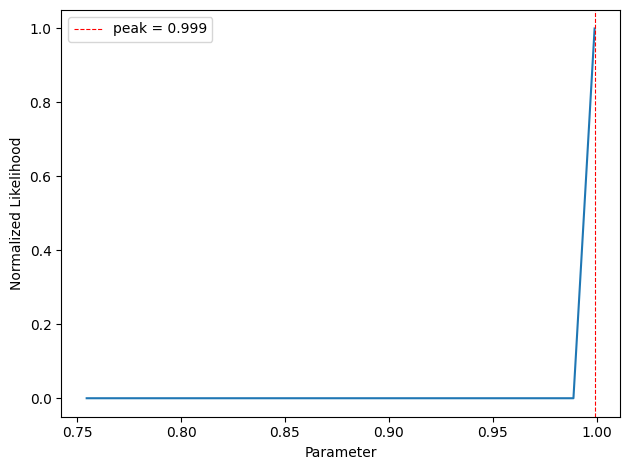

(array([0.5       , 0.51018367, 0.52036735, 0.53055102, 0.54073469,
        0.55091837, 0.56110204, 0.57128571, 0.58146939, 0.59165306,
        0.60183673, 0.61202041, 0.62220408, 0.63238776, 0.64257143,
        0.6527551 , 0.66293878, 0.67312245, 0.68330612, 0.6934898 ,
        0.70367347, 0.71385714, 0.72404082, 0.73422449, 0.74440816,
        0.75459184, 0.76477551, 0.77495918, 0.78514286, 0.79532653,
        0.8055102 , 0.81569388, 0.82587755, 0.83606122, 0.8462449 ,
        0.85642857, 0.86661224, 0.87679592, 0.88697959, 0.89716327,
        0.90734694, 0.91753061, 0.92771429, 0.93789796, 0.94808163,
        0.95826531, 0.96844898, 0.97863265, 0.98881633, 0.999     ]),
 array([3.06568142e-125, 1.14989073e-124, 4.13705156e-124, 1.03921039e-123,
        2.09715810e-123, 2.68894224e-123, 1.90184641e-123, 1.06844748e-123,
        5.50772893e-124, 3.17994863e-158, 5.37383923e-125, 1.04578395e-125,
        9.55610351e-157, 1.14571121e-156, 3.05432303e-156, 1.88901844e-156,
        4.3413

In [30]:
model = model_prior_constrained 


print(f"Model: {model.__class__.__name__}")
is_constrained = hasattr(model.emission, 'phi_tilde')

phi_grid = PHI_GRID_CONSTRAINED if is_constrained else PHI_GRID_FREE                                                 

task_args = [(model, float(phi0), y, X) for phi0 in phi_grid]                                                              

with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:                                                              
    log_likes = np.array(list(executor.map(profile_one_point, task_args))) 


plot_likelihood(phi_grid, log_likes) 